# Modeling Template

This is a template made for loading data from thousands of random Pokemon generation 9 battles from https://pokemonshowdown.com/ and using features from a csv to create models which predict the winner. 

# Outline
## Section 1: Modeling
### 1.1 Logistic Regression
    1.1.1 Baseline model
    1.1.2 Improvements
### 1.2 Decision Tree
### 1.3 Random Forest
### 1.4 
### 1.5
## Section 2: Model Comparisons
### 2.1 AUC score
### 2.2 Cross Validation Score
## Section 3: Best Model Analysis
### 3.1 ROC Curve
### 3.2 Confusion Matrix

In [1]:
# Import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve
from sklearn.metrics import ConfusionMatrixDisplay
from xgboost import XGBClassifier

In [2]:
# Load in training dataframe
path_to_train = "../data/data_cleaned.csv.zip"
full_df = pd.read_csv(path_to_train)

# Eliminate any matches where one player quits prematurely
complete_matches = full_df[(full_df['duration'] > 60) & ((full_df["p1_revealed_team_size"] > 2) | (full_df["p2_revealed_team_size"] > 2))]

# only analyze matches for which we know the players' elo ratings (so that we can use elo_diff as a feature)
train_df = complete_matches[complete_matches['p1elo0'] > 0].copy()
train_df['elo_diff'] =  train_df['p1elo0'] - train_df['p2elo0']

print(train_df.columns.tolist())

# Load in testing dataframe
# path_to_test = "<replace with path to test data csv>"
# test_df = pd.read_csv(path_to_test)
# print(test_df.columns.tolist())

['format', 'id', 'p1_win', 'ratedQ', 'n_turns', 'start_time', 'end_time', 'duration', 'p1name', 'p1side', 'p1elo0', 'p1elo1', 'p2name', 'p2side', 'p2elo0', 'p2elo1', 'type_diversity_diff', 'num_boosting_abilities_diff', 'num_move_boosters_diff', 'total_stat_diff', 'p1_total_adv', 'p1_revealed_team_size', 'p2_revealed_team_size', 'M11_name', 'M11_speciesId', 'M11_used', 'M11_gender', 'M11_shinyQ', 'M11_level', 'M11_ability', 'M11_item', 'M11_teraType', 'M11_role', 'M11_mv1', 'M11_mv2', 'M11_mv3', 'M11_mv4', 'M11_type1', 'M11_type2', 'M11_hp', 'M11_atk', 'M11_def', 'M11_spa', 'M11_spd', 'M11_spe', 'M11_off', 'M12_name', 'M12_speciesId', 'M12_used', 'M12_gender', 'M12_shinyQ', 'M12_level', 'M12_ability', 'M12_item', 'M12_teraType', 'M12_role', 'M12_mv1', 'M12_mv2', 'M12_mv3', 'M12_mv4', 'M12_type1', 'M12_type2', 'M12_hp', 'M12_atk', 'M12_def', 'M12_spa', 'M12_spd', 'M12_spe', 'M12_off', 'M13_name', 'M13_speciesId', 'M13_used', 'M13_gender', 'M13_shinyQ', 'M13_level', 'M13_ability', 'M13_i

# Section 1: Modeling
## 1.1 Logistic Regression
### 1.1.1 Baseline Model

We begin with a simple model using only one feature to predict battle outcome. Following models will add features to see if this baseline model can be improved.

In [3]:
########## BASELINE MODEL ##########
base_feature = ["elo_diff"]
X_train_base = train_df[base_feature]
y_train = train_df["p1_win"]

baseline = LogisticRegression(
    max_iter=10000,
    C=np.inf
)

### 1.1.2 Improvements

In [4]:
########## IMPROVED MODEL ##########
features = [
    "elo_diff",
    "p1_total_adv",
    "total_stat_diff",
    "type_diversity_diff",
    "num_move_boosters_diff",
    "num_boosting_abilities_diff"
]
X_train = train_df[features]

lr = LogisticRegression(
    max_iter=10000,
    C=np.inf
)

## 1.2 Decision Tree

In [5]:
# Do a grid search for decision tree parameters
dt_param_grid = {
    "max_depth": [3, 5, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    param_grid=dt_param_grid,
    cv=5,
    scoring="neg_log_loss",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best parameters:")
print(dt_grid.best_params_)

Best parameters:
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 20}


In [6]:
dt = DecisionTreeClassifier(
    random_state=0,
    max_depth = 3,
    min_samples_leaf= 1,
    min_samples_split= 20
)

## 1.3 Random Forest

In [7]:
# Do a grid search for random forest parameters
rf_param_grid = {
    "max_depth": [4, 6, 8, 10],
    "min_samples_leaf": [5, 10, 20],
    "n_estimators": [200, 500, 800]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid=rf_param_grid,
    cv=5,
    scoring="neg_log_loss",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

Best parameters:
{'max_depth': 4, 'min_samples_leaf': 20, 'n_estimators': 500}


In [8]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=4,
    min_samples_leaf=20,
    random_state=0,
)

## 1.4 Histogram-based Gradient Boosting Classification Tree

In [9]:
# Do a grid search for HistGradientBoosting parameters
hgb_param_grid = {
    "max_depth": [4, 6, 8, 10],
    "min_samples_leaf": [5, 10, 20],
    "max_iter": [100, 200, 500] 
}

grid = GridSearchCV(
    HistGradientBoostingClassifier(random_state=0),
    param_grid=hgb_param_grid,
    cv=5,
    scoring="neg_log_loss",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

Best parameters:
{'max_depth': 4, 'max_iter': 100, 'min_samples_leaf': 20}


In [10]:
hgb = HistGradientBoostingClassifier(
    max_iter=100,
    max_depth=4,
    min_samples_leaf=20,
    random_state=0,
)

## 1.5 XGBoost

In [11]:
# Do a grid search for XGBoost parameters
xgb_param_grid = {
    "max_depth": [4, 6, 8, 10],
    "min_child_weight": [5, 10, 20], 
    "n_estimators": [200, 500, 800] 
}

grid = GridSearchCV(
    XGBClassifier(random_state=0),
    param_grid=xgb_param_grid,
    cv=5,
    scoring="neg_log_loss",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

Best parameters:
{'max_depth': 4, 'min_child_weight': 20, 'n_estimators': 200}


In [12]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    min_child_weight=20,
    random_state=0,
)

# Section 2: Model Comparisons

## 2.1 Cross Validation Score

In [13]:
base_cvscore = cross_val_score(lr, X_train_base, y_train, cv=5, n_jobs=-1,scoring="accuracy")
lr_cvscore = cross_val_score(lr, X_train, y_train, cv=5, n_jobs=-1,scoring="accuracy")
dt_cvscore = cross_val_score(dt, X_train, y_train, cv=5, n_jobs=-1,scoring="accuracy")
rf_cvscore = cross_val_score(rf, X_train, y_train, cv=5, n_jobs=-1,scoring="accuracy")
hgb_cvscore = cross_val_score(hgb, X_train, y_train, cv=5, n_jobs=-1,scoring="accuracy")
xgb_cvscore = cross_val_score(xgb, X_train, y_train, cv=5, n_jobs=-1,scoring="accuracy")

print("Cross-Validation Scores") 
print(f"Baseline Model: {base_cvscore.mean():.3f} +/- {base_cvscore.std():.3f}")
print(f"Logistic Regression: {lr_cvscore.mean():.3f} +/- {lr_cvscore.std():.3f}")
print(f"Decision Tree: {dt_cvscore.mean():.3f} +/- {dt_cvscore.std():.3f}")
print(f"Random Forest: {rf_cvscore.mean():.3f} +/- {rf_cvscore.std():.3f}")
print(f"HistGradientBoosting: {hgb_cvscore.mean():.3f} +/- {hgb_cvscore.std():.3f}")
print(f"XGBoost: {xgb_cvscore.mean():.3f} +/- {xgb_cvscore.std():.3f}")

Cross-Validation Scores
Baseline Model: 0.528 +/- 0.010
Logistic Regression: 0.541 +/- 0.006
Decision Tree: 0.536 +/- 0.007
Random Forest: 0.536 +/- 0.007
HistGradientBoosting: 0.521 +/- 0.008
XGBoost: 0.513 +/- 0.006


# Section 3: Best Model Analysis
## 3.1 ROC Curve

#### Choose best model and uncomment it below
 - Logistic regression model = lr
 - Decision tree model = dt
 - Random forest model = rf

In [14]:
# Choose best model
best_model = lr
#best_model = dt
# best_model = baseline
best_model.fit(X_train,y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",inf
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

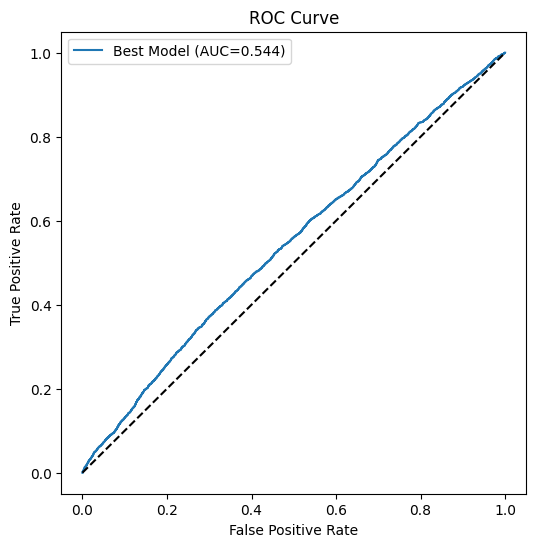

In [15]:
# Random forest
prob = best_model.predict_proba(X_train)[:,1]
fpr, tpr, _ = roc_curve(y_train, prob)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"Best Model (AUC={roc_auc_score(y_train, prob):.3f})"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## 3.2 Confusion Matrix

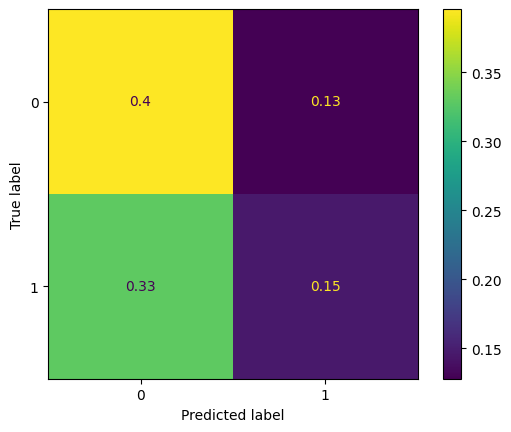

In [16]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_train,
    y_train,
    normalize='all'
)

Note the lack of symmetry.  The model predicts that player 1 will lose 73% of the time when in reality, they lose 53% of the time.  This is likely because of the seeming inherent disadvantage imposed on the p1 slot.  p1 tends to have the player with lower rating (average elo_diff is -15).

In [17]:
print("elo diff mean", X_train["elo_diff"].mean())
print("adv mean", X_train["p1_total_adv"].mean())
print("type div diff mean", X_train["type_diversity_diff"].mean())
print("num_move_boosters_diff mean", X_train["num_move_boosters_diff"].mean())
print("num_boosting_abilities_diff mean",X_train["num_boosting_abilities_diff"].mean())

elo diff mean -13.512630773156417
adv mean 0.07119531336748232
type div diff mean 0.0009356128264012928
num_move_boosters_diff mean -0.001360891383856426
num_boosting_abilities_diff mean -0.017776643701624566


In [18]:
print(f"Probability of losing given a -13 point Elo differential: {1/(1+10**(-13/400))}")

Probability of losing given a -13 point Elo differential: 0.5186997779295586


<Axes: xlabel='elo_diff', ylabel='Count'>

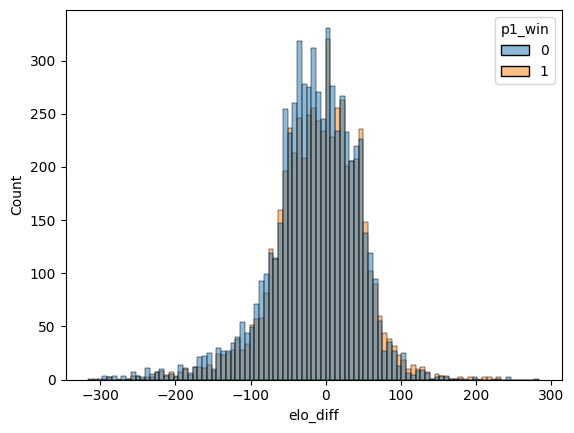

In [19]:
import seaborn as sns

sns.histplot(data=train_df, x='elo_diff', hue='p1_win')

In [20]:
train_df["predictions"] = lr.predict(X_train[features])

<Axes: xlabel='elo_diff', ylabel='Count'>

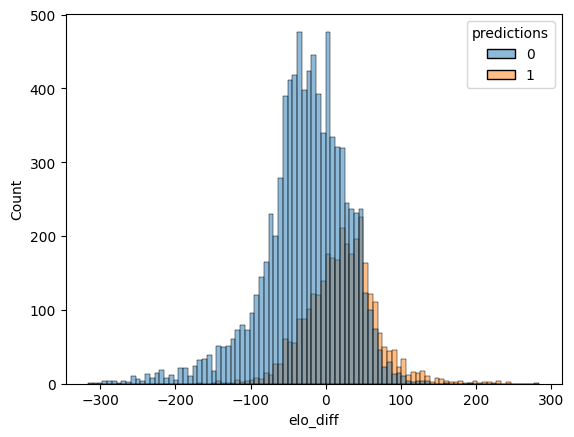

In [21]:
sns.histplot(data = train_df,x='elo_diff',hue='predictions')

<Axes: xlabel='p1_total_adv', ylabel='Count'>

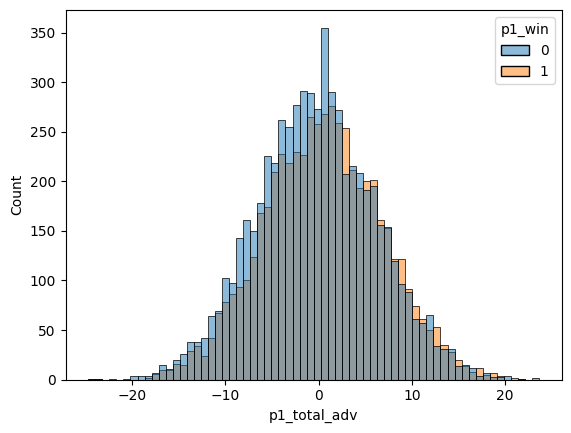

In [22]:
sns.histplot(data=train_df,x='p1_total_adv',hue='p1_win')

<Axes: xlabel='p1_total_adv', ylabel='Count'>

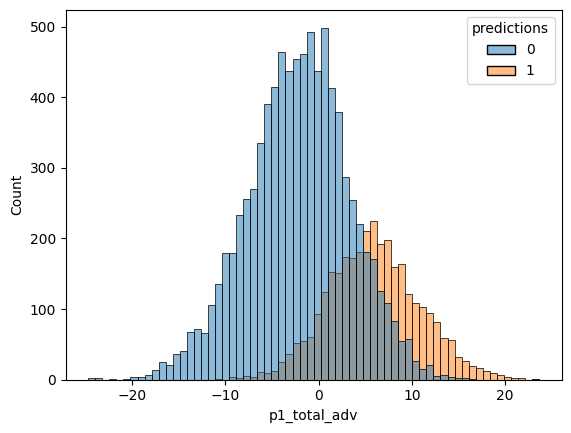

In [23]:
sns.histplot(data=train_df,x='p1_total_adv',hue='predictions')